In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')

print(deliveries_df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [4]:
team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "RPS": "Rising Pune Supergiants"
}

deliveries_df["bowling_team"] = deliveries_df["bowling_team"].replace(team_mapping)
deliveries_df["batting_team"] = deliveries_df["batting_team"].replace(team_mapping)

In [5]:
deliveries_df['extra_runs'] = deliveries_df['extra_runs'].fillna(0)
deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('none')

deliveries_df_filtered = deliveries_df[deliveries_df['inning'].isin([1, 2])].copy()

extras_per_match = deliveries_df_filtered.groupby(
    ['match_id', 'bowling_team', 'inning']
)['extra_runs'].sum().reset_index()

avg_extras = extras_per_match.groupby(
    ['bowling_team', 'inning']
)['extra_runs'].mean().reset_index(name='avg_extras_per_match')

display(avg_extras)

,bowling_team,inning,avg_extras_per_match
0,Chennai Super Kings,1,7.722222
1,Chennai Super Kings,2,7.753846
2,Deccan Chargers,1,9.187500
3,Deccan Chargers,2,8.488372
4,Delhi Capitals,1,8.194245
5,Delhi Capitals,2,7.616071
6,Gujarat Lions,1,5.625000
7,Gujarat Lions,2,7.000000
8,Gujarat Titans,1,6.500000
9,Gujarat Titans,2,6.619048


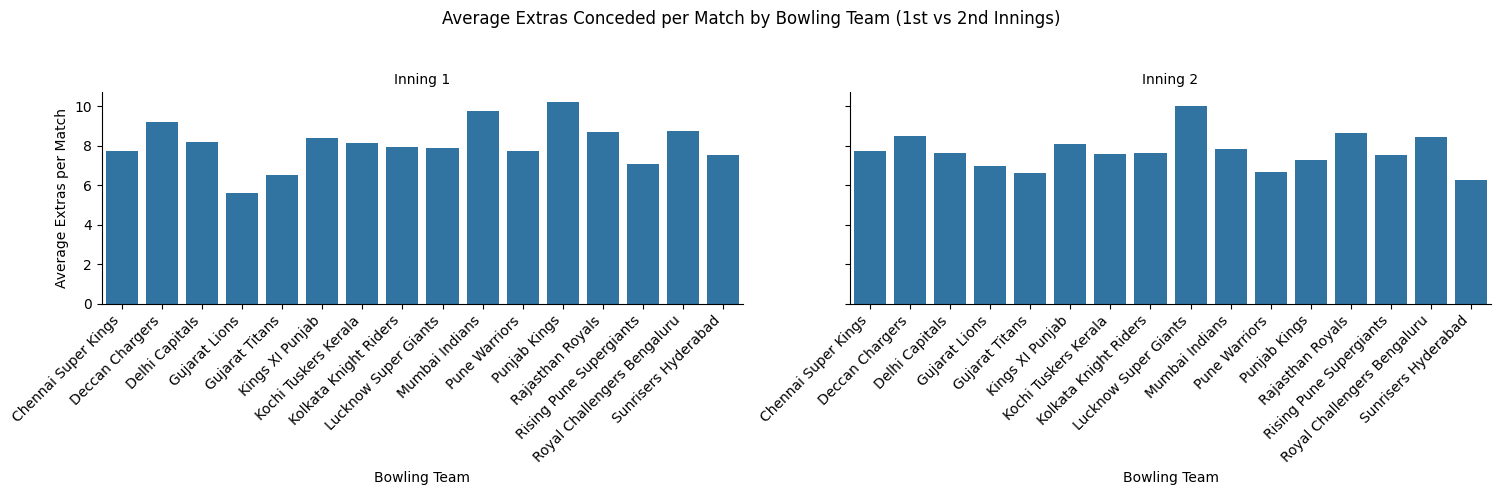

In [7]:
g = sns.catplot(
    data=avg_extras,
    x='bowling_team',
    y='avg_extras_per_match',
    col='inning',
    kind='bar',
    height=5,
    aspect=1.5
)

g.set_axis_labels('Bowling Team', 'Average Extras per Match')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')

plt.suptitle('Average Extras Conceded per Match by Bowling Team (1st vs 2nd Innings)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()